In [114]:
# Core PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Torchvision for ResNeXt and transforms
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Data loading
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import Dataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

# OpenCV for video processing
import cv2

# Utilities
import numpy as np
import pandas as pd
from PIL import Image
import os
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import seaborn as sns

In [115]:
class VideoDatasetFromFolders(Dataset):
    def __init__(self, root_dir, num_frames=16, transform=None):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.transform = transform
        self.classes = {'real': 0, 'fake': 1}
        self.samples = []

        for label in ['real', 'fake']:
            class_dir = os.path.join(root_dir, label)
            for fname in os.listdir(class_dir):
                if fname.endswith('.mp4'):
                    self.samples.append((os.path.join(class_dir, fname), self.classes[label]))

    def __len__(self):
        return len(self.samples)

    def _load_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        interval = max(total_frames // self.num_frames, 1)
        frames = []

        for i in range(self.num_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        # Pad if not enough frames
        while len(frames) < self.num_frames:
            frames.append(torch.zeros_like(frames[0]))

        return torch.stack(frames)  # [T, C, H, W]

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = self._load_frames(video_path)
        return frames, label

In [116]:
transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406],
              std=[0.229, 0.224, 0.225])
])

train_dataset = VideoDatasetFromFolders(
    root_dir='./dataset/train',
    num_frames=8,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)
print(f"[DEBUG] Number of training samples: {len(train_loader.dataset)}")

test_dataset = VideoDatasetFromFolders(
    root_dir='./dataset/test',
    num_frames=8,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)
print(f"[DEBUG] Number of test samples: {len(test_loader.dataset)}")

[DEBUG] Number of training samples: 403
[DEBUG] Number of test samples: 40


In [117]:
# Load pre-trained ResNeXt model
# Using ResNeXt-101 with 32x8d architecture for high-quality feature extraction
def get_feature_extractor(device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = models.resnext101_32x8d(pretrained=True)
    
    # Remove the final fully connected layer to get features
    feature_extractor = nn.Sequential(*list(model.children())[:-1])
    feature_extractor.eval()  # Set to evaluation mode
    feature_extractor.to(device)
    
    return feature_extractor

# Initialize the feature extractor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = get_feature_extractor(device)
print(f"[DEBUG] Using device: {device}")

[DEBUG] Using device: cuda


In [118]:
# Function to extract features from a dataset
def extract_features(dataloader, feature_extractor, device):
    all_features = []
    all_labels = []
    
    with torch.no_grad():  # No need to track gradients
        for frames, labels in tqdm(dataloader, desc="Extracting features"):
            batch_size, num_frames, channels, height, width = frames.shape
            
            # Reshape to process all frames
            frames_reshaped = frames.view(-1, channels, height, width).to(device)
            
            # Extract features
            features = feature_extractor(frames_reshaped)
            # Reshape back: [batch_size * num_frames, feature_dim] -> [batch_size, num_frames, feature_dim]
            features = features.view(batch_size, num_frames, -1)
            
            # Store features and labels
            all_features.append(features.cpu())
            all_labels.append(labels)
    
    return torch.cat(all_features, dim=0), torch.cat(all_labels, dim=0)

# Extract features from training set
print("Extracting features from training set...")
train_features, train_labels = extract_features(train_loader, feature_extractor, device)

# Extract features from test set
print("Extracting features from test set...")
test_features, test_labels = extract_features(test_loader, feature_extractor, device)

Extracting features from training set...


Extracting features: 100%|██████████| 202/202 [10:05<00:00,  3.00s/it]


Extracting features from test set...


Extracting features: 100%|██████████| 20/20 [00:10<00:00,  1.92it/s]


In [119]:
# Save the extracted features to disk
def save_features(features, labels, filename):
    torch.save({
        'features': features,
        'labels': labels
    }, filename)
    print(f"Saved features to {filename}")

# Create directory for features if it doesn't exist
os.makedirs('./features', exist_ok=True)

# Save training features
save_features(train_features, train_labels, './features/train_resnext_features.pt')

# Save test features
save_features(test_features, test_labels, './features/test_resnext_features.pt')

# Print feature shapes for verification
print(f"Training features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Feature dimension per frame: {train_features.shape[-1]}")

Saved features to ./features/train_resnext_features.pt
Saved features to ./features/test_resnext_features.pt
Training features shape: torch.Size([403, 8, 2048])
Test features shape: torch.Size([40, 8, 2048])
Feature dimension per frame: 2048


In [120]:

def load_features(filename):
    data = torch.load(filename)
    return data['features'], data['labels']


loaded_train_features, loaded_train_labels = load_features('./features/train_resnext_features.pt')
print(f"Loaded training features shape: {loaded_train_features.shape}")

Loaded training features shape: torch.Size([403, 8, 2048])


In [121]:
# Define the LSTM model for video classification
class VideoLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout=0.5):
        super(VideoLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,  # input shape (batch, seq, feature)
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # Use bidirectional LSTM for better context capture
        )
        
        # Attention layer - helps focus on important frames
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),  # *2 for bidirectional
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        
        # Output classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def attention_net(self, lstm_output):
        # lstm_output shape: (batch_size, seq_len, hidden_dim*2)
        attention_weights = self.attention(lstm_output)  # (batch_size, seq_len, 1)
        attention_weights = torch.softmax(attention_weights, dim=1)  # (batch_size, seq_len, 1)
        context = torch.sum(attention_weights * lstm_output, dim=1)  # (batch_size, hidden_dim*2)
        return context
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        # LSTM forward pass
        lstm_out, _ = self.lstm(x)  # (batch_size, seq_len, hidden_dim*2)
        
        # Apply attention mechanism
        attn_out = self.attention_net(lstm_out)  # (batch_size, hidden_dim*2)
        
        # Final classification
        output = self.classifier(attn_out)
        return output

In [122]:
# Set up model parameters and training configuration
input_dim = train_features.shape[-1]  # 2048 for ResNeXt-101 features
hidden_dim = 512
num_layers = 2
num_classes = 2  # Real (0) or Fake (1)
dropout = 0.5

# Create model instance
model = VideoLSTM(input_dim, hidden_dim, num_layers, num_classes, dropout)
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5,)

print(f"Input feature dimension: {input_dim}")
print(model)

Input feature dimension: 2048
VideoLSTM(
  (lstm): LSTM(2048, 512, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=2, bias=True)
  )
)


In [123]:
# Create feature dataset for training
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create feature datasets
train_feature_dataset = FeatureDataset(train_features, train_labels)
test_feature_dataset = FeatureDataset(test_features, test_labels)

# Create dataloaders for features
batch_size = 16
train_feature_loader = DataLoader(train_feature_dataset, batch_size=batch_size, shuffle=True)
test_feature_loader = DataLoader(test_feature_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_feature_loader)}")
print(f"Test batches: {len(test_feature_loader)}")

Training batches: 26
Test batches: 3


In [124]:
# Training and evaluation functions
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for features, labels in tqdm(dataloader, desc="Training"):
        features = features.to(device)
        labels = labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        for features, labels in tqdm(dataloader, desc="Evaluating"):
            features = features.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            # Store labels and predictions for metrics calculation
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
            # Get probabilities for ROC curve
            probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # Probability of class 1 (fake)
            all_probabilities.extend(probs)
    
    # Calculate metrics
    total = len(all_labels)
    eval_loss = running_loss / total
    eval_acc = accuracy_score(all_labels, all_predictions)
    eval_precision = precision_score(all_labels, all_predictions, average='binary')
    eval_recall = recall_score(all_labels, all_predictions, average='binary')
    eval_f1 = f1_score(all_labels, all_predictions, average='binary')
    
    return {
        'loss': eval_loss,
        'accuracy': eval_acc,
        'precision': eval_precision,
        'recall': eval_recall,
        'f1': eval_f1,
        'labels': all_labels,
        'predictions': all_predictions,
        'probabilities': all_probabilities
    }

In [125]:
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, patience=7):
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_acc:.4f}")
        
        # Evaluate
        val_metrics = evaluate(model, val_loader, criterion, device)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_f1 = val_metrics['f1']
        
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")
        print(f"Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}")
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

# Train the model
model, history = train_model(
    model=model,
    train_loader=train_feature_loader,
    val_loader=test_feature_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=10,
    patience=7
)


Epoch 1/10


Training: 100%|██████████| 26/26 [00:00<00:00, 48.12it/s]


Training Loss: 0.6974, Training Accuracy: 0.4839


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 163.91it/s]


Validation Loss: 0.6955, Validation Accuracy: 0.5000, F1: 0.6552
Precision: 0.5000, Recall: 0.9500

Epoch 2/10


...

Validation Loss: 1.2877, Validation Accuracy: 0.4750, F1: 0.3226
Precision: 0.4545, Recall: 0.2500

Epoch 8/10


Training: 100%|██████████| 26/26 [00:00<00:00, 56.75it/s]


Training Loss: 0.4430, Training Accuracy: 0.8015


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 324.57it/s]

Validation Loss: 1.2421, Validation Accuracy: 0.4500, F1: 0.3529
Precision: 0.4286, Recall: 0.3000
Early stopping triggered after 8 epochs!


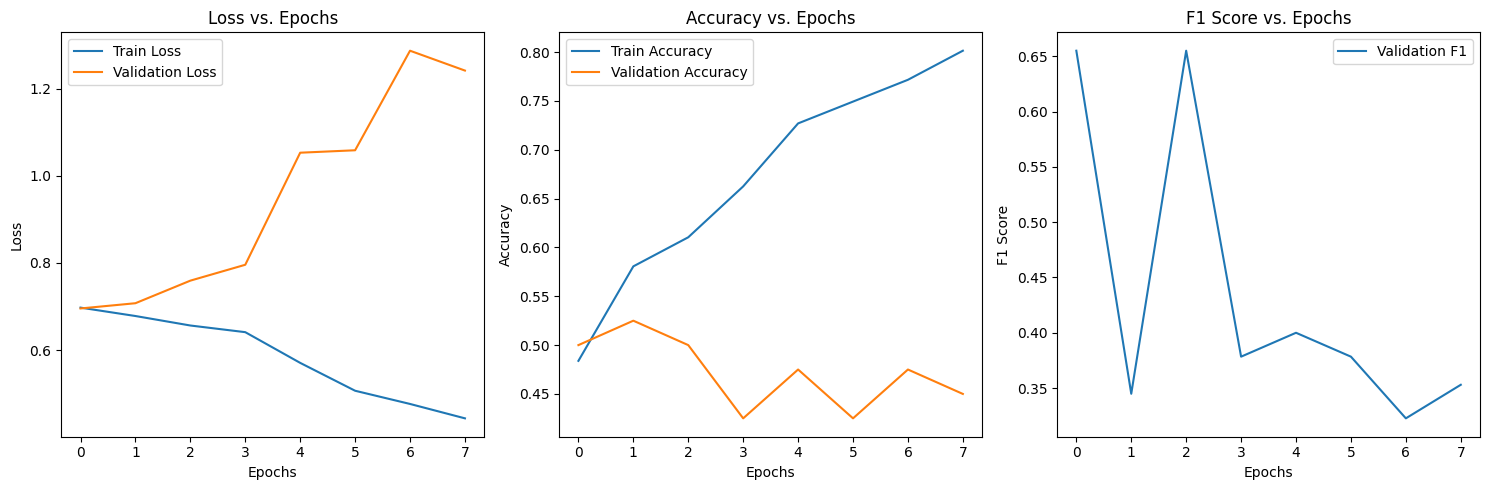

In [126]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot loss
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot F1 score
plt.subplot(1, 3, 3)
plt.plot(history['val_f1'], label='Validation F1')
plt.title('F1 Score vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

Evaluating: 100%|██████████| 3/3 [00:00<00:00, 252.04it/s]


Final Test Results:
Loss: 1.2421
Accuracy: 0.4500
Precision: 0.4286
Recall: 0.3000
F1 Score: 0.3529


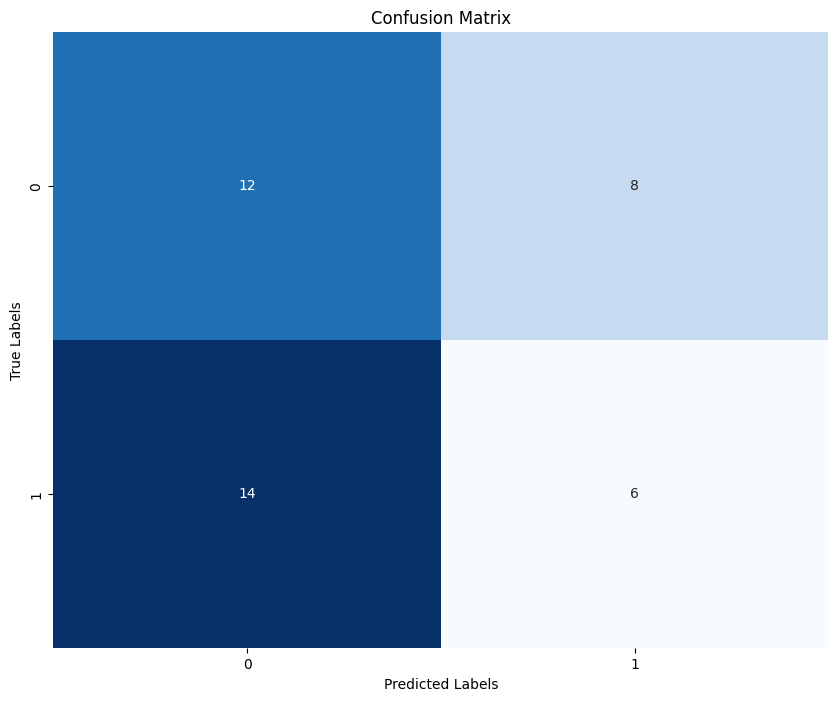

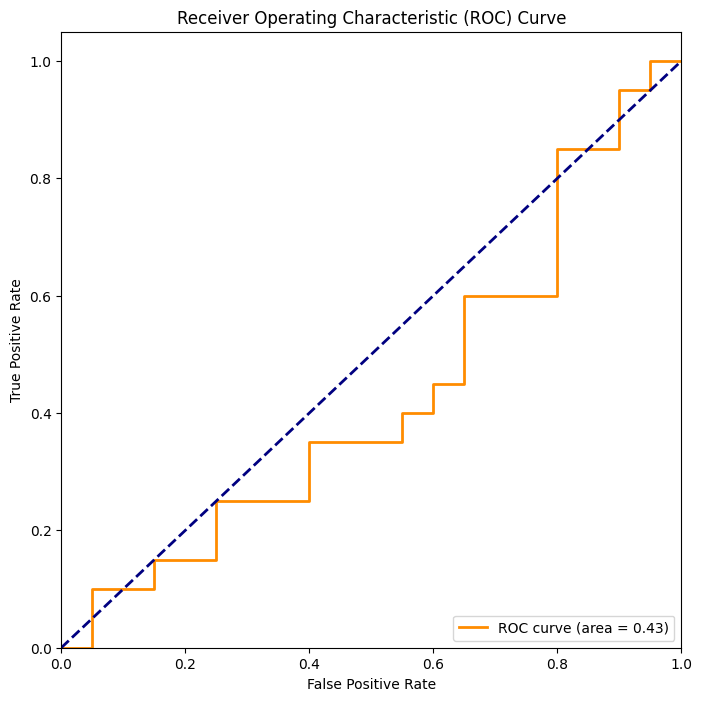

In [127]:
# Final evaluation on test set
final_metrics = evaluate(model, test_feature_loader, criterion, device)

print(f"\nFinal Test Results:")
print(f"Loss: {final_metrics['loss']:.4f}")
print(f"Accuracy: {final_metrics['accuracy']:.4f}")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall: {final_metrics['recall']:.4f}")
print(f"F1 Score: {final_metrics['f1']:.4f}")

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(final_metrics['labels'], final_metrics['probabilities'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [128]:
# Save the trained model
os.makedirs('./models', exist_ok=True)
save_path = './models/df_lstm_model.pt'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'architecture': {
        'input_dim': input_dim,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'num_classes': num_classes,
        'dropout': dropout
    },
    'metrics': {
        'accuracy': final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1']
    }
}, save_path)

print(f"Model saved to {save_path}")

Model saved to ./models/df_lstm_model.pt


In [129]:
# Load the model (for future use)
def load_model(model_path):
    checkpoint = torch.load(model_path)
    
    # Create a new model with the same architecture
    arch = checkpoint['architecture']
    loaded_model = VideoLSTM(
        input_dim=arch['input_dim'],
        hidden_dim=arch['hidden_dim'],
        num_layers=arch['num_layers'],
        num_classes=arch['num_classes'],
        dropout=arch['dropout']
    )
    
    # Load the trained weights
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()  # Set to evaluation mode
    
    return loaded_model

# Example usage:
# loaded_model = load_model('./models/df_lstm_model.pt')
# new_predictions = loaded_model(new_features.to(device))